# Neural Network Training

This notebook trains a feedforward neural network for binary classification on the processed student depression dataset.

The target label is expected to be encoded as `-1` and `1` in the processed CSV.

In [ ]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
MODEL_PATH = SRC_DIR / "models" / "nn_model_1.npz"

for path in (PROJECT_ROOT, SRC_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import models.nn_model_utils as nn_model_utils  # noqa: E402
nn_model_utils = importlib.reload(nn_model_utils)

BinaryMLPClassifier = nn_model_utils.BinaryMLPClassifier
load_processed_dataset = nn_model_utils.load_processed_dataset
prepare_binary_classification_data = nn_model_utils.prepare_binary_classification_data

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\irira\Documents\Efrei\ING2\S8\Convex Optimization\Project\Convex-Optimization


In [9]:
clean_data_path = PROJECT_ROOT / "data" / "processed" / "clean_student_data.csv"

df = load_processed_dataset(clean_data_path)
X, y, feature_names = prepare_binary_classification_data(df)

print(f"Dataset shape: {df.shape}")
print(f"Feature count: {len(feature_names)}")
print(f"Class distribution (encoded): {dict(pd.Series(y).value_counts().sort_index())}")
print(df.head())

Dataset shape: (100000, 18)
Feature count: 17
Class distribution (encoded): {0.0: 89938, 1.0: 10062}
        Age      CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0  0.495403  0.772553        0.262011    -0.612083           -0.069468   
1 -0.504411 -0.228120       -0.909858     1.361535            1.679202   
2 -0.504411  0.305063       -0.974962    -1.118139           -1.145572   
3 -0.004504  1.444970        0.265221    -1.269956            0.737610   
4 -1.004318  0.544076       -0.063508    -0.966322            0.535841   

   Physical_Activity  Stress_Level  Transportation_Time  Student_Debt  \
0           0.914222      0.609728             0.480073             0   
1           1.559878     -1.496801            -0.666320             0   
2           1.444582     -0.794625             0.265124             1   
3           1.283168     -0.794625             1.411518             1   
4          -1.622284      1.311904            -0.021474             0   

   Part_Time_Jo

In [10]:
rng = np.random.default_rng(42)
indices = rng.permutation(len(X))
X = X[indices]
y = y[indices]

# Hold out a completely untouched test set first.
test_ratio = 0.10
test_size = int(len(X) * test_ratio)
X_test = X[:test_size]
y_test = y[:test_size]

# Use the remaining data only for training and validation.
X_train_pool = X[test_size:]
y_train_pool = y[test_size:]

validation_ratio = 0.20
validation_size = int(len(X_train_pool) * validation_ratio)
X_validation = X_train_pool[:validation_size]
y_validation = y_train_pool[:validation_size]
X_train = X_train_pool[validation_size:]
y_train = y_train_pool[validation_size:]

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_validation.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Test set size: {len(X_test)} samples, never used during training")

Train shape: (72000, 17)
Validation shape: (18000, 17)
Test shape: (10000, 17)
Test set size: 10000 samples, never used during training


In [13]:
if MODEL_PATH.exists():
    model = BinaryMLPClassifier.load(MODEL_PATH)
    history = model.history
    print(f"Loaded saved model from {MODEL_PATH}")
else:
    model = BinaryMLPClassifier(
        input_dim=X_train.shape[1],
        hidden_layers=(64, 32),
        learning_rate=1e-3,
        epochs=25,
        batch_size=128,
        optimizer="adam",
        l2_penalty=1e-4,
        seed=42,
    )

    history = model.fit(
        X_train,
        y_train,
        X_validation=X_validation,
        y_validation=y_validation,
        verbose=True,
    )
    model.save(MODEL_PATH)
    print(f"Saved trained model to {MODEL_PATH}")

Epoch 001/25 | loss=0.3095 | acc=0.9003 | val_loss=0.3184 | val_acc=0.8980
Epoch 002/25 | loss=0.3049 | acc=0.9003 | val_loss=0.3145 | val_acc=0.8981
Epoch 003/25 | loss=0.3032 | acc=0.9003 | val_loss=0.3139 | val_acc=0.8980
Epoch 004/25 | loss=0.2993 | acc=0.9004 | val_loss=0.3105 | val_acc=0.8978
Epoch 005/25 | loss=0.2980 | acc=0.9005 | val_loss=0.3089 | val_acc=0.8980
Epoch 006/25 | loss=0.2970 | acc=0.9005 | val_loss=0.3077 | val_acc=0.8982
Epoch 007/25 | loss=0.2975 | acc=0.9005 | val_loss=0.3092 | val_acc=0.8971
Epoch 008/25 | loss=0.2950 | acc=0.9007 | val_loss=0.3070 | val_acc=0.8980
Epoch 009/25 | loss=0.2952 | acc=0.9006 | val_loss=0.3081 | val_acc=0.8977
Epoch 010/25 | loss=0.2943 | acc=0.9004 | val_loss=0.3069 | val_acc=0.8973
Epoch 011/25 | loss=0.2937 | acc=0.9007 | val_loss=0.3058 | val_acc=0.8977
Epoch 012/25 | loss=0.2940 | acc=0.9005 | val_loss=0.3082 | val_acc=0.8971
Epoch 013/25 | loss=0.2934 | acc=0.9007 | val_loss=0.3072 | val_acc=0.8966
Epoch 014/25 | loss=0.292

In [18]:
train_metrics = model.evaluate(X_train, y_train)
validation_metrics = model.evaluate(X_validation, y_validation)
test_metrics = model.evaluate(X_test, y_test)

print("Train metrics:", train_metrics)
print("Validation metrics:", validation_metrics)
print("Test metrics:", test_metrics)

predictions = model.predict(X_test)
np.unique(predictions, return_counts=True)


Train metrics: {'loss': 0.2903009208841727, 'accuracy': 0.9007361111111111}
Validation metrics: {'loss': 0.30651967353352455, 'accuracy': 0.8966666666666666}
Test metrics: {'loss': 0.30621343199683, 'accuracy': 0.8949}


(array([-1,  1]), array([9905,   95], dtype=int64))

In [17]:
np.unique(y_test, return_counts=True)

(array([0., 1.]), array([8946, 1054], dtype=int64))

Figures and metrics will be saved to: C:\Users\irira\Documents\Efrei\ING2\S8\Convex Optimization\Project\Convex-Optimization\notebooks\outputs\figures


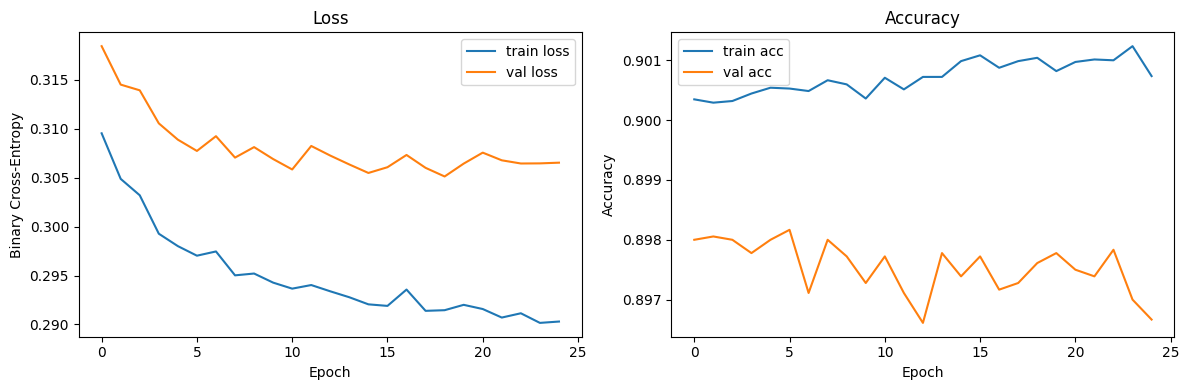

Test set metrics:
{'accuracy': 0.8949,
 'f1': 0.08529155787641428,
 'precision': 0.5157894736842106,
 'recall': 0.046489563567362426,
 'roc_auc': 0.7080105554261685}

Classification report:
              precision    recall  f1-score   support

           0     0.8985    0.9949    0.9442      8946
           1     0.5158    0.0465    0.0853      1054

    accuracy                         0.8949     10000
   macro avg     0.7072    0.5207    0.5148     10000
weighted avg     0.8582    0.8949    0.8537     10000



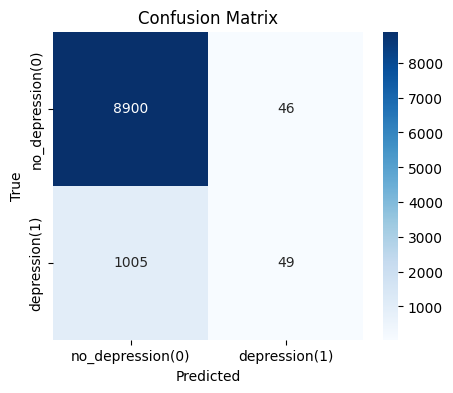

Saved figures and metrics to C:\Users\irira\Documents\Efrei\ING2\S8\Convex Optimization\Project\Convex-Optimization\notebooks\outputs\figures


In [20]:
# Visualization & metrics setup
import matplotlib.pyplot as plt
from pathlib import Path
import json

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from sklearn.metrics import (
        roc_curve, roc_auc_score,
        precision_recall_curve, average_precision_score,
        confusion_matrix, classification_report,
        precision_score, recall_score, f1_score,
    )
except Exception:
    raise ImportError("Please install scikit-learn: pip install scikit-learn")

OUT_DIR = Path.cwd().resolve() / "outputs" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures and metrics will be saved to: {OUT_DIR}")

# --- Training / validation loss and accuracy curves ---
hist = model.history

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist.train_loss, label="train loss")
plt.plot(hist.validation_loss, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.train_accuracy, label="train acc")
plt.plot(hist.validation_accuracy, label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "train_val_curves.png", dpi=150)
plt.show()

# --- Core performance metrics and classification report ---
y_test_prob = model.predict_proba(X_test)
y_test_pred = (y_test_prob >= 0.5).astype(int)
y_true = y_test.astype(int)

metrics = {
    "accuracy": float((y_test_pred == y_true).mean()),
    "precision": precision_score(y_true, y_test_pred, zero_division=0),
    "recall": recall_score(y_true, y_test_pred, zero_division=0),
    "f1": f1_score(y_true, y_test_pred, zero_division=0),
    "roc_auc": float(roc_auc_score(y_true, y_test_prob)),
}

from pprint import pprint
print("Test set metrics:")
pprint(metrics)

print("\nClassification report:")
print(classification_report(y_true, y_test_pred, digits=4, zero_division=0))


# --- Confusion matrix heatmap ---
cm = confusion_matrix(y_true, y_test_pred)
labels = ["no_depression(0)","depression(1)"]

plt.figure(figsize=(5,4))
if sns is not None:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
else:
    plt.imshow(cm, cmap="Blues")
    for (i,j), val in np.ndenumerate(cm):
        plt.text(j, i, int(val), ha="center", va="center")
    plt.xticks([0,1], labels)
    plt.yticks([0,1], labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

# --- Save a metrics summary JSON ---
summary = {"metrics": metrics}
with open(OUT_DIR / "metrics_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved figures and metrics to {OUT_DIR}")
